### 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path

from bs4 import BeautifulSoup

### 2. Load the dataset

In [2]:
# Load the dataset
df = pd.read_csv("/home/surendran-g/Documents/AI_Job_Recommendation_System/dataset/Resume.csv")
print(df.shape)

(2484, 4)


### 3. Basic Checks

In [3]:
print(df.head())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


In [4]:
print(df.dtypes)

ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


In [5]:
print(df['Category'].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [6]:
#Load PDFs from category folders
import glob

pdf_files = glob.glob("/home/surendran-g/Documents/AI_Job_Recommendation_System/dataset/data/ACCOUNTANT/78403342.pdf", recursive=True)

# Build a dataframe from file paths
records = []
for path in pdf_files:
    category = os.path.basename(os.path.dirname(path))
    filename = os.path.basename(path)
    size_kb = os.path.getsize(path) / 1024
    records.append({"category": category, "filename": filename, "size_kb": round(size_kb, 2), "path": path})

pdf_df = pd.DataFrame(records)
print(pdf_df.shape)
print(pdf_df.head())
print(pdf_df['category'].value_counts())

(1, 4)
     category      filename  size_kb  \
0  ACCOUNTANT  78403342.pdf    24.26   

                                                path  
0  /home/surendran-g/Documents/AI_Job_Recommendat...  
category
ACCOUNTANT    1
Name: count, dtype: int64


### 4. Quqlity Checks

In [7]:
# Shape 
print("Shape (rows × cols):", df.shape)
print(f"  → {df.shape[0]:,} resumes, {df.shape[1]} columns\n")

# Column data types
print("Data types:")
print(df.dtypes)
print()

# Memory usage
print("Memory usage per column:")
print(df.memory_usage(deep=True).apply(lambda x: f"{x/1024:.1f} KB"))
print(f"\nTotal memory: {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print()

# Quick peek 
print("First 2 rows:")
df.head(2)

Shape (rows × cols): (2484, 4)
  → 2,484 resumes, 4 columns

Data types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object

Memory usage per column:
Index              0.1 KB
ID                19.4 KB
Resume_str     25229.5 KB
Resume_html    62699.7 KB
Category         141.9 KB
dtype: str

Total memory: 88090.5 KB

First 2 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR


In [8]:
# Missing values
# Null counts per column
null_counts = df.isnull().sum()
null_pct   = (null_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "null_count" : null_counts,
    "null_pct"   : null_pct,
    "dtype"      : df.dtypes
})
print("Missing value summary:")
print(missing_df.to_string())
print()

# Empty string check (whitespace-only counts as missing too)
print("Empty / whitespace-only strings:")
for col in ["Resume_str", "Resume_html", "Category"]:
    empty = (df[col].astype(str).str.strip() == "").sum()
    print(f"  {col:<16}: {empty}")
print()

# Rows with ANY null 
rows_with_null = df.isnull().any(axis=1).sum()
print(f"Rows with at least one null: {rows_with_null}")

# Category coverage
print(f"\nDistinct categories: {df['Category'].nunique()}")
print("Category null check:", df['Category'].isnull().sum())

Missing value summary:
             null_count  null_pct  dtype
ID                    0       0.0  int64
Resume_str            0       0.0    str
Resume_html           0       0.0    str
Category              0       0.0    str

Empty / whitespace-only strings:
  Resume_str      : 1
  Resume_html     : 0
  Category        : 0

Rows with at least one null: 0

Distinct categories: 24
Category null check: 0


In [9]:
# Duplication Check
# Duplicate IDs
dup_ids = df[df.duplicated(subset="ID", keep=False)]
print(f"Duplicate IDs   : {df.duplicated(subset='ID').sum()}")
if not dup_ids.empty:
    print("Rows with duplicate IDs:")
    print(dup_ids[["ID", "Category"]])

# Duplicate Resume_str
dup_text = df.duplicated(subset="Resume_str").sum()
print(f"Duplicate Resume_str: {dup_text}")
print()

# Full-row duplicates 
dup_full = df.duplicated().sum()
print(f"Full-row duplicates  : {dup_full}")
print()

# Show any duplicate Resume_str pairs 
if dup_text > 0:
    dup_rows = df[df.duplicated(subset="Resume_str", keep=False)]
    print("Rows with duplicate Resume_str:")
    print(dup_rows[["ID", "Category"]].sort_values("Category").to_string())
else:
    print("All Resume_str entries are unique.")

Duplicate IDs   : 0
Duplicate Resume_str: 2

Full-row duplicates  : 0

Rows with duplicate Resume_str:
            ID  Category
2444  16850314  AVIATION
2483  37473139  AVIATION
1490  19147603   FINANCE
1509  28398216   FINANCE


In [10]:
# Quality check summary
# Consolidated EDA summary 
summary = {
    "Total resumes"         : df.shape[0],
    "Total columns"         : df.shape[1],
    "Missing values"        : df.isnull().sum().sum(),
    "Duplicate IDs"         : df.duplicated(subset="ID").sum(),
    "Duplicate Resume_str"  : df.duplicated(subset="Resume_str").sum(),
    "Full-row duplicates"   : df.duplicated().sum(),
    "Unique categories"     : df["Category"].nunique(),
    "Dataset clean?"        : all([
        df.isnull().sum().sum() == 0,
        df.duplicated(subset="ID").sum() == 0,
        df.duplicated(subset="Resume_str").sum() == 0
    ])
}
print("EDA Summary")
for k, v in summary.items():
    flag = "" if v == 0 or v is True else ("" if v is False else "")
    print(f"  {k:<26}: {v}  {flag}")

EDA Summary
  Total resumes             : 2484  
  Total columns             : 4  
  Missing values            : 0  
  Duplicate IDs             : 0  
  Duplicate Resume_str      : 2  
  Full-row duplicates       : 0  
  Unique categories         : 24  
  Dataset clean?            : False  


### 5. Target Variable Analysis 

In [11]:
# Build class_counts — works on ALL pandas versions 
counts_series = df["Category"].value_counts()   # Series: index=category, values=count

class_counts = pd.DataFrame({
    "category" : counts_series.index,
    "count"    : counts_series.values,
})

# Add pct column explicitly
class_counts["pct"] = (class_counts["count"] / class_counts["count"].sum() * 100).round(2)
class_counts = class_counts.reset_index(drop=True)

print("Columns:", class_counts.columns.tolist())
print(f"Total categories : {len(class_counts)}")
print(f"Max count : {class_counts['count'].max()}  ({class_counts.iloc[0]['category']})")
print(f"Min count : {class_counts['count'].min()}  ({class_counts.iloc[-1]['category']})")
print()
print(class_counts.to_string(index=False))

Columns: ['category', 'count', 'pct']
Total categories : 24
Max count : 120  (INFORMATION-TECHNOLOGY)
Min count : 22  (BPO)

              category  count  pct
INFORMATION-TECHNOLOGY    120 4.83
  BUSINESS-DEVELOPMENT    120 4.83
              ADVOCATE    118 4.75
                  CHEF    118 4.75
               FINANCE    118 4.75
           ENGINEERING    118 4.75
            ACCOUNTANT    118 4.75
               FITNESS    117 4.71
              AVIATION    117 4.71
                 SALES    116 4.67
            HEALTHCARE    115 4.63
            CONSULTANT    115 4.63
               BANKING    115 4.63
          CONSTRUCTION    112 4.51
      PUBLIC-RELATIONS    111 4.47
                    HR    110 4.43
              DESIGNER    107 4.31
                  ARTS    103 4.15
               TEACHER    102 4.11
               APPAREL     97 3.90
         DIGITAL-MEDIA     96 3.86
           AGRICULTURE     63 2.54
            AUTOMOBILE     36 1.45
                   BPO     22 0.89


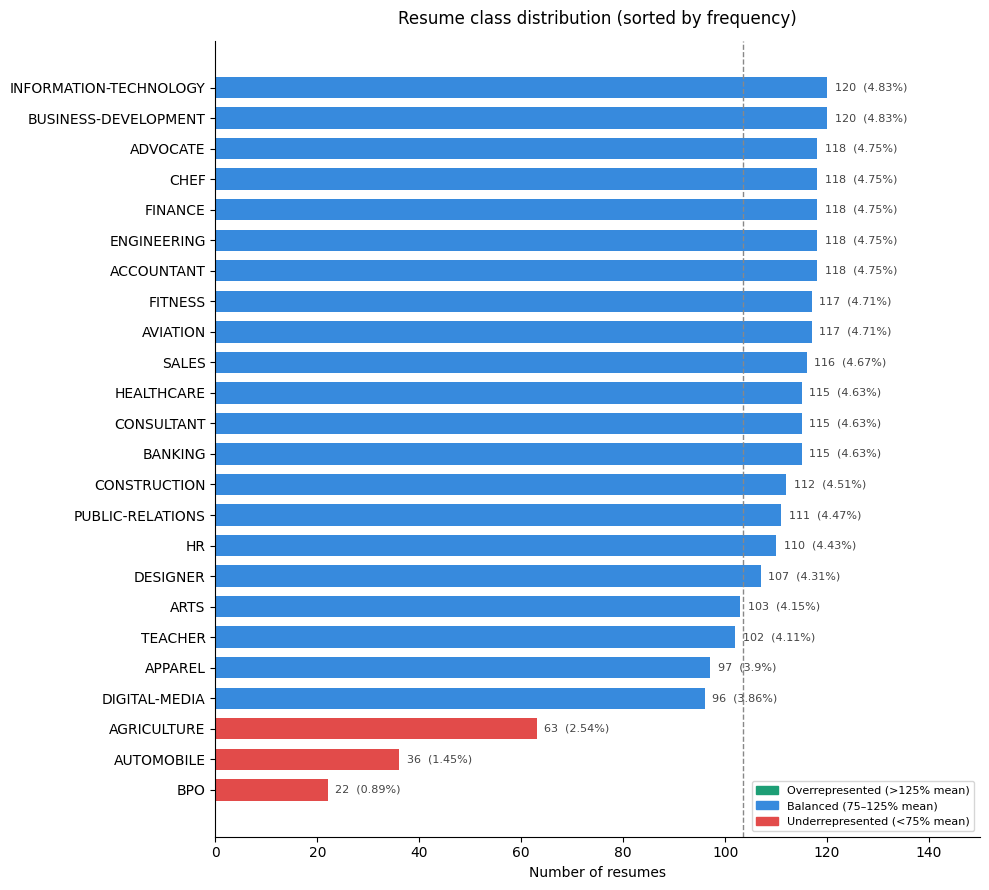

In [12]:

# Colour-code by imbalance severity
mean_count     = class_counts["count"].mean()
threshold_low  = mean_count * 0.75
threshold_high = mean_count * 1.25

def get_color(c):
    if c < threshold_low:  return "#E24B4A"   # red  – underrepresented
    if c > threshold_high: return "#1D9E75"   # teal – overrepresented
    return "#378ADD"                             # blue – balanced

colors = [get_color(c) for c in class_counts["count"]]

# Plot 
fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    class_counts["category"],
    class_counts["count"],
    color=colors, edgecolor="none", height=0.7
)
ax.invert_yaxis()

# Labels at end of each bar — uses class_counts directly
for bar, row in zip(bars, class_counts.itertuples()):
    ax.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row.count}  ({row.pct}%)",
        va="center", fontsize=8, color="#444"
    )

# Mean reference line 
ax.axvline(mean_count, color="#888", linestyle="--", linewidth=1,
           label=f"Mean = {mean_count:.0f}")

# Legend 
patches = [
    mpatches.Patch(color="#1D9E75", label="Overrepresented (>125% mean)"),
    mpatches.Patch(color="#378ADD", label="Balanced (75–125% mean)"),
    mpatches.Patch(color="#E24B4A", label="Underrepresented (<75% mean)"),
]
ax.legend(handles=patches, fontsize=8, loc="lower right")

ax.set_xlabel("Number of resumes", fontsize=10)
ax.set_title("Resume class distribution (sorted by frequency)",
             fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, class_counts["count"].max() + 30)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
def imbalance_flag(c):
    if c < mean_count * 0.75: return " underrepresented"
    if c > mean_count * 1.25: return " overrepresented"
    return " balanced"

class_counts["status"] = class_counts["count"].apply(imbalance_flag)

print(f"Mean per class : {mean_count:.1f}\n")
print(class_counts[["category", "count", "pct", "status"]].to_string(index=False))
print("\nStatus summary:")
print(class_counts["status"].value_counts().to_string())

Mean per class : 103.5

              category  count  pct            status
INFORMATION-TECHNOLOGY    120 4.83          balanced
  BUSINESS-DEVELOPMENT    120 4.83          balanced
              ADVOCATE    118 4.75          balanced
                  CHEF    118 4.75          balanced
               FINANCE    118 4.75          balanced
           ENGINEERING    118 4.75          balanced
            ACCOUNTANT    118 4.75          balanced
               FITNESS    117 4.71          balanced
              AVIATION    117 4.71          balanced
                 SALES    116 4.67          balanced
            HEALTHCARE    115 4.63          balanced
            CONSULTANT    115 4.63          balanced
               BANKING    115 4.63          balanced
          CONSTRUCTION    112 4.51          balanced
      PUBLIC-RELATIONS    111 4.47          balanced
                    HR    110 4.43          balanced
              DESIGNER    107 4.31          balanced
                  ARTS

### 6. Directory Cross-Validation

In [14]:
DATASET_ROOT = Path("/home/surendran-g/Documents/AI_Job_Recommendation_System/dataset")
PDF_ROOT     = DATASET_ROOT / "data"      
CSV_PATH     = DATASET_ROOT / "Resume.csv" 

print("Path Check")
print(f"PDF_ROOT exists : {PDF_ROOT.exists()}")
print(f"CSV_PATH exists : {CSV_PATH.exists()}")
print()
cats = sorted([p.name for p in PDF_ROOT.iterdir() if p.is_dir()])
print(f"Category folders : {cats}")
print(f"Total            : {len(cats)}")

Path Check
PDF_ROOT exists : True
CSV_PATH exists : True

Category folders : ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Total            : 24


In [15]:
# Directory traversal 
pdf_records = []
for category_dir in sorted(PDF_ROOT.iterdir()):
    if not category_dir.is_dir(): continue
    for pdf_file in sorted(category_dir.glob("*.pdf")):
        try:    file_id = int(pdf_file.stem)
        except ValueError: file_id = None
        pdf_records.append({
            "file_id"    : file_id,
            "folder_cat" : category_dir.name,
            "filename"   : pdf_file.name,
            "size_kb"    : round(pdf_file.stat().st_size / 1024, 2),
        })

if not pdf_records:
    raise RuntimeError("No PDFs found — check PDF_ROOT in Cell 1.")

pdf_df = pd.DataFrame(pdf_records)
print(f"Total PDFs scanned      : {len(pdf_df):,}")
print(f"Unique category folders : {pdf_df['folder_cat'].nunique()}")
print(f"Non-numeric filenames   : {pdf_df['file_id'].isna().sum()}")
print()
print("PDFs per folder:")
print(pdf_df.groupby("folder_cat").size().sort_values(ascending=False).to_string())

Total PDFs scanned      : 2,484
Unique category folders : 24
Non-numeric filenames   : 0

PDFs per folder:
folder_cat
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


In [16]:
# Load CSV & normalise category names 
df = pd.read_csv(CSV_PATH)
df["cat_norm"]       = df["Category"].str.upper().str.strip()
pdf_df["folder_norm"] = pdf_df["folder_cat"].str.upper().str.strip()

csv_cats    = set(df["cat_norm"].unique())
folder_cats = set(pdf_df["folder_norm"].unique())

print(f"CSV unique categories    : {len(csv_cats)}")
print(f"Folder unique categories : {len(folder_cats)}")

only_in_csv    = csv_cats - folder_cats
only_in_folder = folder_cats - csv_cats
if only_in_csv:    print(f"⚠ In CSV but no folder  : {sorted(only_in_csv)}")
if only_in_folder: print(f"⚠ Folder but not in CSV : {sorted(only_in_folder)}")
if not only_in_csv and not only_in_folder:
    print("All category names match between CSV and folders")

CSV unique categories    : 24
Folder unique categories : 24
All category names match between CSV and folders


In [17]:
# Four-way integrity check 
csv_id_to_cat = dict(zip(df["ID"].astype(int), df["cat_norm"]))
csv_pairs     = set(zip(df["ID"].astype(int), df["cat_norm"]))

pdf_valid             = pdf_df[pdf_df["file_id"].notna()].copy()
pdf_valid["file_id"]  = pdf_valid["file_id"].astype(int)
pdf_pairs             = set(zip(pdf_valid["file_id"], pdf_valid["folder_norm"]))

orphaned   = pdf_pairs - csv_pairs
missing    = csv_pairs - pdf_pairs
mismatches = [
    {"id": fid, "folder": fcat, "csv_cat": csv_id_to_cat[fid]}
    for fid, fcat in zip(pdf_valid["file_id"], pdf_valid["folder_norm"])
    if fid in csv_id_to_cat and csv_id_to_cat[fid] != fcat
]
non_numeric = pdf_df[pdf_df["file_id"].isna()]

print("Integrity Check Results")
print(f"  PDFs on disk              : {len(pdf_df):,}")
print(f"  Rows in CSV               : {len(df):,}")
print()
print(f"  [1] Orphaned PDFs         : {len(orphaned)}")
print(f"  [2] Missing PDFs          : {len(missing)}")
print(f"  [3] Category mismatches   : {len(mismatches)}")
print(f"  [4] Non-numeric filenames : {len(non_numeric)}")
print()
if orphaned:
    print("Orphaned PDFs:")
    for fid, fcat in sorted(orphaned): print(f"  {fcat}/{fid}.pdf")
if missing:
    print("Missing PDFs:")
    for fid, fcat in sorted(missing):  print(f"  {fcat}/{fid}.pdf")
if mismatches:
    print("Category mismatches:")
    print(pd.DataFrame(mismatches).to_string(index=False))

Integrity Check Results
  PDFs on disk              : 2,484
  Rows in CSV               : 2,484

  [1] Orphaned PDFs         : 0
  [2] Missing PDFs          : 0
  [3] Category mismatches   : 0
  [4] Non-numeric filenames : 0



In [18]:
# Per-category count reconciliation 
pdf_counts = pdf_df.groupby("folder_norm").size().reset_index(name="pdf_count")
csv_counts = df.groupby("cat_norm").size().reset_index(name="csv_count")
csv_counts.rename(columns={"cat_norm": "folder_norm"}, inplace=True)

recon = pdf_counts.merge(csv_counts, on="folder_norm", how="outer")
recon["diff"]   = recon["pdf_count"].fillna(0).astype(int) - \
                  recon["csv_count"].fillna(0).astype(int)
recon["status"] = recon["diff"].apply(
    lambda d: "match" if d == 0 else ("⚠ extra PDFs" if d > 0 else " missing PDFs")
)
print("Per-category reconciliation:")
print(recon.sort_values("folder_norm").to_string(index=False))
print(f"\nAll categories match: {(recon['diff'] == 0).all()}")

Per-category reconciliation:
           folder_norm  pdf_count  csv_count  diff status
            ACCOUNTANT        118        118     0  match
              ADVOCATE        118        118     0  match
           AGRICULTURE         63         63     0  match
               APPAREL         97         97     0  match
                  ARTS        103        103     0  match
            AUTOMOBILE         36         36     0  match
              AVIATION        117        117     0  match
               BANKING        115        115     0  match
                   BPO         22         22     0  match
  BUSINESS-DEVELOPMENT        120        120     0  match
                  CHEF        118        118     0  match
          CONSTRUCTION        112        112     0  match
            CONSULTANT        115        115     0  match
              DESIGNER        107        107     0  match
         DIGITAL-MEDIA         96         96     0  match
           ENGINEERING        118        11

In [19]:
# Export integrity_report.csv 
pdf_valid2               = pdf_valid.copy()
pdf_valid2["csv_category"] = pdf_valid2["file_id"].map(csv_id_to_cat)

def row_status(row):
    if pd.isna(row["csv_category"]):              return "orphaned_pdf"
    if row["csv_category"] != row["folder_norm"]: return "category_mismatch"
    return "ok"

pdf_valid2["status"] = pdf_valid2.apply(row_status, axis=1)

missing_rows = pd.DataFrame([
    {"file_id": fid, "folder_cat": None,
     "csv_category": fcat, "status": "missing_pdf"}
    for fid, fcat in missing
])
report = pd.concat([pdf_valid2, missing_rows], ignore_index=True)
report.to_csv("integrity_report.csv", index=False)

print("Status breakdown:")
print(report["status"].value_counts().to_string())
print("\nSaved → integrity_report.csv")

Status breakdown:
status
ok    2484

Saved → integrity_report.csv


### 7. Text Metrics Analysis

In [20]:
# Feature engineering: length columns
df["char_count"] = df["Resume_str"].str.len()
df["word_count"] = df["Resume_str"].str.split().str.len()
df["sent_count"] = df["Resume_str"].str.count(r"[.!?]+")  # rough sentence proxy
df["avg_word_len"] = df["char_count"] / df["word_count"]

print("New columns added:", ["char_count", "word_count", "sent_count", "avg_word_len"])
print()
print("── Word count summary ──────────────────────────────")
print(df["word_count"].describe().round(1).to_string())
print()
print("── Character count summary ─────────────────────────")
print(df["char_count"].describe().round(1).to_string())
print()
print("Shortest resume:", df["word_count"].min(),
      "words →", df.loc[df["word_count"].idxmin(), "Category"])
print("Longest resume :", df["word_count"].max(),
      "words →", df.loc[df["word_count"].idxmax(), "Category"])

New columns added: ['char_count', 'word_count', 'sent_count', 'avg_word_len']

── Word count summary ──────────────────────────────
count    2484.0
mean      811.3
std       371.0
min         0.0
25%       651.0
50%       757.0
75%       933.0
max      5190.0

── Character count summary ─────────────────────────
count     2484.0
mean      6295.3
std       2769.3
min         21.0
25%       5160.0
50%       5886.5
75%       7227.2
max      38842.0

Shortest resume: 0 words → BUSINESS-DEVELOPMENT
Longest resume : 5190 words → PUBLIC-RELATIONS


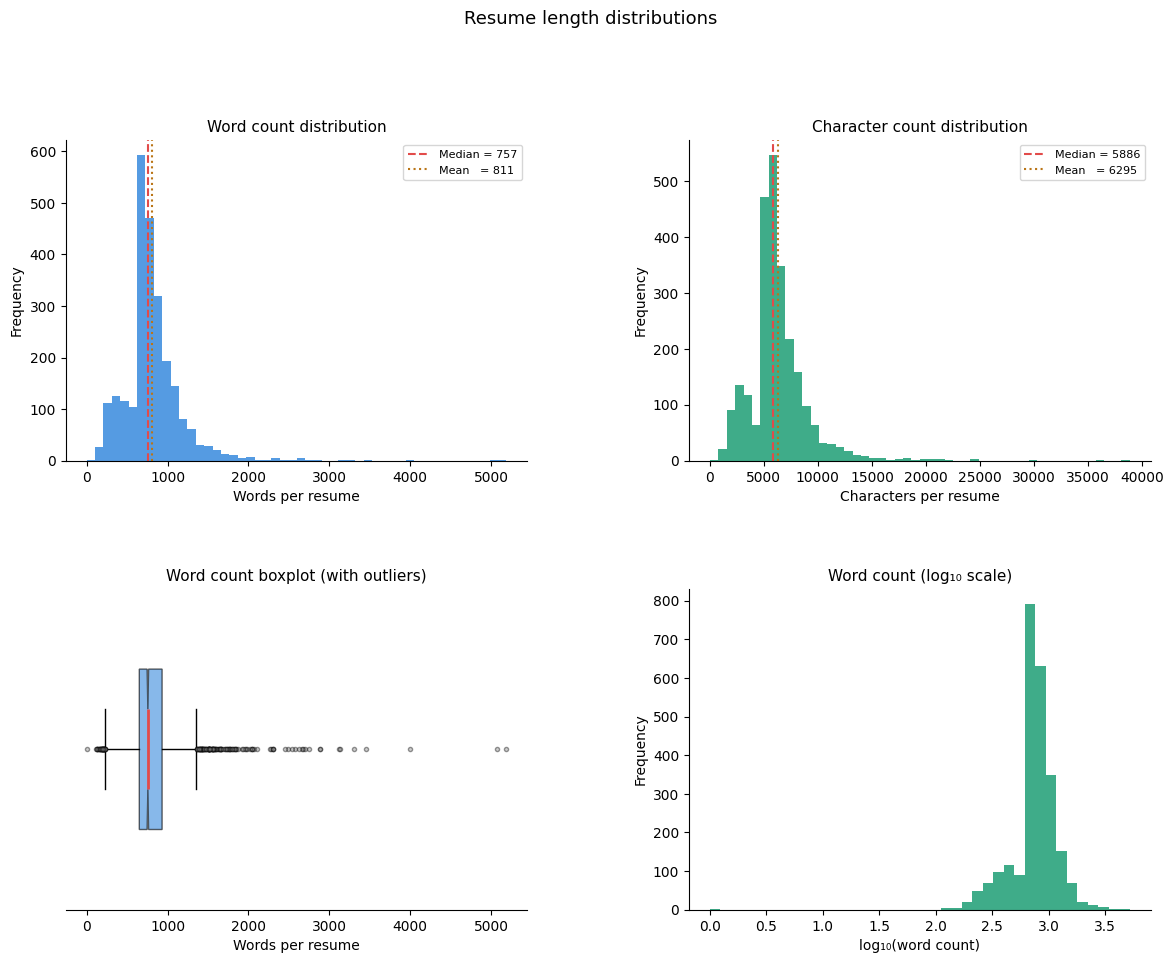

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

C1, C2 = "#378ADD", "#1D9E75"

# Word count histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["word_count"], bins=50, color=C1, edgecolor="none", alpha=0.85)
ax1.axvline(df["word_count"].median(), color="#E24B4A", lw=1.5,
            linestyle="--", label=f"Median = {df['word_count'].median():.0f}")
ax1.axvline(df["word_count"].mean(), color="#BA7517", lw=1.5,
            linestyle=":", label=f"Mean   = {df['word_count'].mean():.0f}")
ax1.set_title("Word count distribution", fontsize=11)
ax1.set_xlabel("Words per resume"); ax1.set_ylabel("Frequency")
ax1.legend(fontsize=8)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

# Character count histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["char_count"], bins=50, color=C2, edgecolor="none", alpha=0.85)
ax2.axvline(df["char_count"].median(), color="#E24B4A", lw=1.5,
            linestyle="--", label=f"Median = {df['char_count'].median():.0f}")
ax2.axvline(df["char_count"].mean(), color="#BA7517", lw=1.5,
            linestyle=":", label=f"Mean   = {df['char_count'].mean():.0f}")
ax2.set_title("Character count distribution", fontsize=11)
ax2.set_xlabel("Characters per resume"); ax2.set_ylabel("Frequency")
ax2.legend(fontsize=8)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

#  Word count boxplot
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot(df["word_count"], vert=False, patch_artist=True,
                 widths=0.5, notch=True,
                 boxprops=dict(facecolor=C1, alpha=0.6),
                 medianprops=dict(color="#E24B4A", lw=2),
                 flierprops=dict(marker="o", markersize=3,
                                 markerfacecolor="#888", alpha=0.4))
ax3.set_title("Word count boxplot (with outliers)", fontsize=11)
ax3.set_xlabel("Words per resume")
ax3.set_yticks([])
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
ax3.spines["left"].set_visible(False)

# Log-scale word count to reveal tail
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(np.log10(df["word_count"] + 1), bins=40,
         color=C2, edgecolor="none", alpha=0.85)
ax4.set_title("Word count (log₁₀ scale)", fontsize=11)
ax4.set_xlabel("log₁₀(word count)"); ax4.set_ylabel("Frequency")
ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)

fig.suptitle("Resume length distributions", fontsize=13, y=1.01)
plt.savefig("length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4907/490077895.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


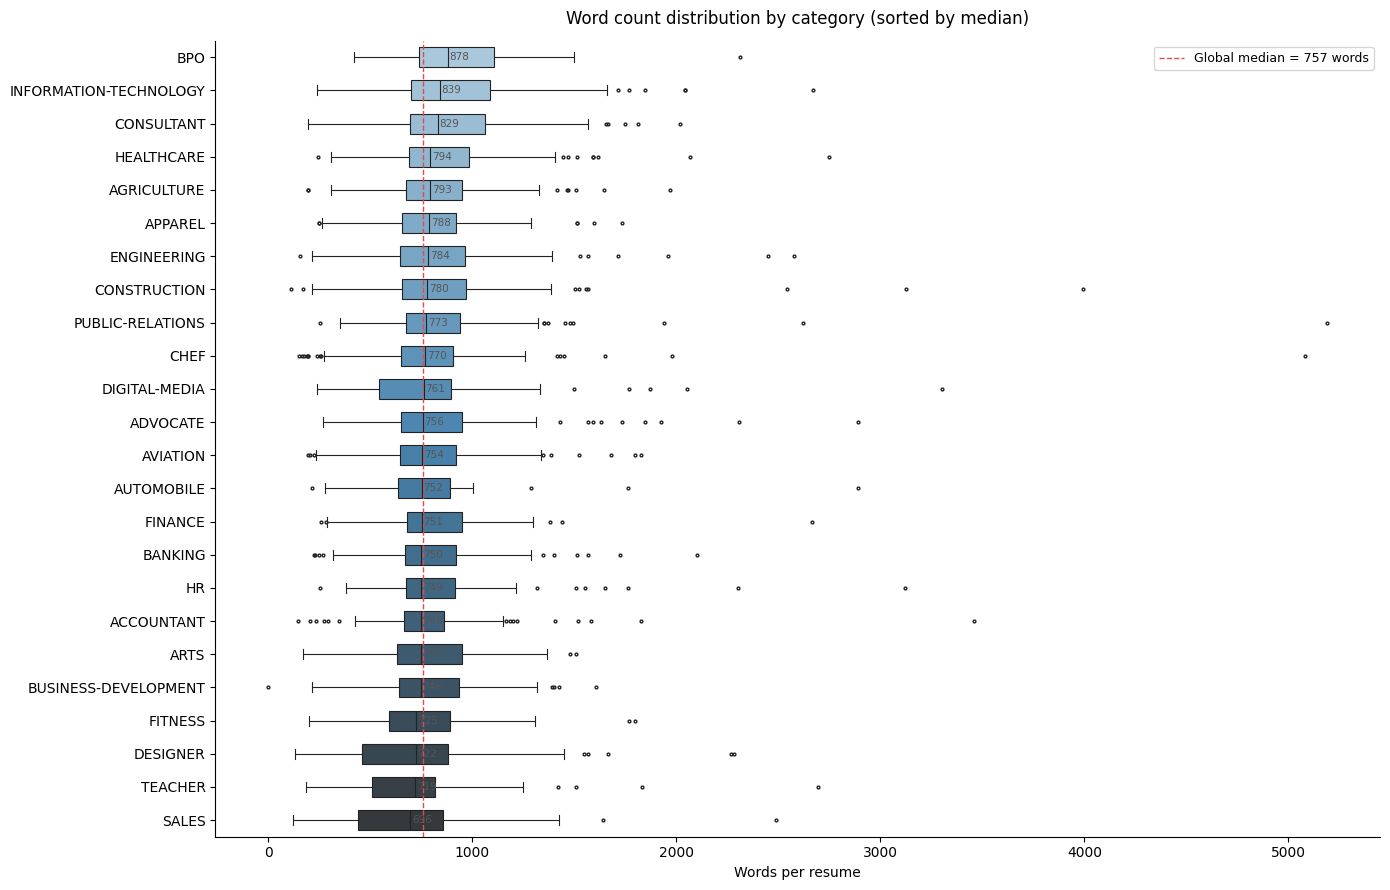

In [22]:
# Sort categories by median word count 
cat_order = (
    df.groupby("Category")["word_count"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(14, 9))

sns.boxplot(
    data=df,
    x="word_count",
    y="Category",
    order=cat_order,
    palette="Blues_d",
    width=0.6,
    fliersize=2,
    linewidth=0.8,
    ax=ax
)

# Overlay category median as text label 
medians = df.groupby("Category")["word_count"].median()
for i, cat in enumerate(cat_order):
    ax.text(medians[cat] + 8, i, f"{medians[cat]:.0f}",
            va="center", fontsize=7.5, color="#555")

# Global median reference line 
global_median = df["word_count"].median()
ax.axvline(global_median, color="#E24B4A", lw=1, linestyle="--",
           label=f"Global median = {global_median:.0f} words")

ax.set_title("Word count distribution by category (sorted by median)",
             fontsize=12, pad=12)
ax.set_xlabel("Words per resume", fontsize=10)
ax.set_ylabel("")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("word_count_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Per-category aggregation
cat_stats = (
    df.groupby("Category")["word_count"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(1)
    .sort_values("median", ascending=False)
)

print("Word count stats by category (sorted by median):\n")
print(cat_stats.to_string())

print("\n── Top 5 most verbose categories (median words) ────")
print(cat_stats["median"].head(5).to_string())

print("\n── Top 5 most concise categories (median words) ────")
print(cat_stats["median"].tail(5).to_string())

Word count stats by category (sorted by median):

                        count   mean  median    std  min   max
Category                                                      
BPO                        22  974.2   878.0  395.4  420  2310
INFORMATION-TECHNOLOGY    120  926.6   839.0  383.4  237  2670
CONSULTANT                115  879.7   829.0  344.2  194  2018
HEALTHCARE                115  881.8   794.0  331.7  242  2749
AGRICULTURE                63  856.3   793.0  325.6  192  1970
APPAREL                    97  780.6   788.0  290.4  250  1735
ENGINEERING               118  837.6   783.5  363.6  156  2579
CONSTRUCTION              112  852.7   779.5  511.3  113  3994
PUBLIC-RELATIONS          111  889.3   773.0  519.8  253  5190
CHEF                      118  797.0   770.0  508.7  149  5080
DIGITAL-MEDIA              96  792.2   761.0  424.8  237  3301
ADVOCATE                  118  848.5   756.5  372.1  266  2888
AVIATION                  117  791.2   754.0  308.1  195  1829
AUTOM

In [24]:
# IQR-based outlier detection on word_count 
Q1  = df["word_count"].quantile(0.25)
Q3  = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

short_outliers = df[df["word_count"] < lower][
    ["ID", "Category", "word_count", "char_count"]
].sort_values("word_count")

long_outliers  = df[df["word_count"] > upper][
    ["ID", "Category", "word_count", "char_count"]
].sort_values("word_count", ascending=False)

print(f"IQR bounds: [{lower:.0f}, {upper:.0f}] words")
print(f"Short outliers (< {lower:.0f} words) : {len(short_outliers)}")
print(f"Long  outliers (> {upper:.0f} words) : {len(long_outliers)}")
print()
print("Short outliers:")
print(short_outliers.head(10).to_string(index=False))
print()
print("Long outliers (top 10):")
print(long_outliers.head(10).to_string(index=False))

# Tag in dataframe for later filtering 
df["length_flag"] = "normal"
df.loc[df["word_count"] < lower, "length_flag"] = "short_outlier"
df.loc[df["word_count"] > upper, "length_flag"] = "long_outlier"
print()
print("length_flag counts:")
print(df["length_flag"].value_counts().to_string())

IQR bounds: [228, 1356] words
Short outliers (< 228 words) : 40
Long  outliers (> 1356 words) : 135

Short outliers:
      ID             Category  word_count  char_count
12632728 BUSINESS-DEVELOPMENT           0          21
22965804         CONSTRUCTION         113         881
12696104                SALES         122        1033
14381464                SALES         128         995
21705160             DESIGNER         131         985
78149576             DESIGNER         134        1181
24799301           ACCOUNTANT         143        1210
35468363                 CHEF         149        1130
21298336          ENGINEERING         156        1400
47317494                 CHEF         164        1349

Long outliers (top 10):
      ID         Category  word_count  char_count
11842274 PUBLIC-RELATIONS        5190       35933
14663897             CHEF        5080       38842
39908485     CONSTRUCTION        3994       30055
10554236       ACCOUNTANT        3459       24695
23085604    DI

### 8. HTML vs. String Comparison

In [25]:
from bs4 import BeautifulSoup

# Look at raw HTML of first resume 
sample_html = df["Resume_html"].iloc[0]
soup = BeautifulSoup(sample_html, "html.parser")

print("── First 800 chars of raw HTML ─────────────────────")
print(sample_html[:800])
print()

# All unique tags present
all_tags = sorted(set(t.name for t in soup.find_all()))
print("── Tags found in this resume ───────────────────────")
print(all_tags)
print()

# Text from HTML vs Resume_str 
html_text = soup.get_text(separator=" ", strip=True)
str_text  = df["Resume_str"].iloc[0]
print(f"HTML stripped word count : {len(html_text.split())}")
print(f"Resume_str word count    : {len(str_text.split())}")
print(f"Texts identical          : {html_text.strip() == str_text.strip()}")

── First 800 chars of raw HTML ─────────────────────
<div class="fontsize fontface vmargins hmargins linespacing pagesize" id="document"> <div class="section firstsection" id="SECTION_NAME500375979" style="
      padding-top:0px;
    "> <div class="paragraph PARAGRAPH_NAME firstparagraph" id="PARAGRAPH_500375979_1_326506904" style="
      padding-top:0px;
    "> <div class="name" itemprop="name"> <span class="field fName" id="500375979FNAM1"> </span> <span> </span> <span class="field" id="500375979LNAM1"> HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR</span> </div> </div> </div> <div class="section" id="SECTION_SUMM500375981" style="
      padding-top:0px;
    "> <div class="heading bottomborder"> <div class="sectiontitle" id="SECTNAME_SUMM500375981"> Summary</div> </div> <div class="paragraph firstparagraph" id="PARAGRAPH_500375981_

── Tags found in this resume ───────────────────────
['b', 'br', 'div', 'li', 'p', 'span', 'table', 'tbody', 'td', 'tr', 'u', 'ul']

HTML strippe

In [26]:
import pandas as pd
from collections import Counter

# Count tag occurrences across all 2484 resumes 
tag_counter  = Counter()
tag_presence = Counter()   # how many resumes have each tag at all

for html in df["Resume_html"]:
    s    = BeautifulSoup(html, "html.parser")
    tags = [t.name for t in s.find_all()]
    tag_counter.update(tags)
    tag_presence.update(set(tags))

tag_df = pd.DataFrame({
    "tag"            : list(tag_counter.keys()),
    "total_count"    : list(tag_counter.values()),
    "resumes_with_tag": [tag_presence[t] for t in tag_counter.keys()],
})
tag_df["pct_resumes"] = (tag_df["resumes_with_tag"] / len(df) * 100).round(1)
tag_df = tag_df.sort_values("total_count", ascending=False).reset_index(drop=True)

print("Tag frequency across all resumes:")
print(tag_df.to_string(index=False))

Tag frequency across all resumes:
                           tag  total_count  resumes_with_tag  pct_resumes
                          span       250932              2483        100.0
                           div       117274              2484        100.0
                            li        97339              2444         98.4
                            ul        15865              2444         98.4
                            br        12834              1812         72.9
                             p        10219              1208         48.6
                            td         4212              1945         78.3
                          font         2148               464         18.7
                            tr         2026              1945         78.3
                         tbody         1988              1945         78.3
                         table         1988              1945         78.3
                             b          624               105     

In [27]:
# Check whether section headings appear in bold/h tags 
SECTION_KEYWORDS = [
    "skill", "experience", "education", "summary",
    "objective", "project", "certification", "award"
]

def extract_sections(html):
    """Return dict of section_name → text for each detected section."""
    soup    = BeautifulSoup(html, "html.parser")
    found   = {}
    heading_tags = soup.find_all(["b", "strong", "h1", "h2", "h3"])
    for tag in heading_tags:
        text = tag.get_text(strip=True).lower()
        for kw in SECTION_KEYWORDS:
            if kw in text:
                # Grab sibling/following text as section body
                sibling_text = ""
                for sib in tag.find_next_siblings()[:5]:
                    sibling_text += " " + sib.get_text(" ", strip=True)
                found[kw] = sibling_text.strip()[:300]
                break
    return found

# Apply to all resumes & measure section detection rate 
df["sections"]    = df["Resume_html"].apply(extract_sections)
df["n_sections"]  = df["sections"].apply(len)

print("Section detection rate across all resumes:")
for kw in SECTION_KEYWORDS:
    count = df["sections"].apply(lambda s: kw in s).sum()
    print(f"  {kw:<16}: {count:4d}  ({count/len(df)*100:.1f}%)")

print()
print("Resumes with 0 detected sections:",
      (df["n_sections"] == 0).sum())

Section detection rate across all resumes:
  skill           :   18  (0.7%)
  experience      :   12  (0.5%)
  education       :    4  (0.2%)
  summary         :    2  (0.1%)
  objective       :    4  (0.2%)
  project         :   22  (0.9%)
  certification   :    9  (0.4%)
  award           :    9  (0.4%)

Resumes with 0 detected sections: 2419


In [28]:
# Compare text content: stripped HTML vs Resume_str 
def html_to_text(html):
    return BeautifulSoup(html, "html.parser").get_text(
        separator=" ", strip=True
    )

df["html_text"]      = df["Resume_html"].apply(html_to_text)
df["html_word_count"] = df["html_text"].str.split().str.len()

# Word count delta (html_stripped - resume_str)
df["word_delta"] = df["html_word_count"] - df["word_count"]

print("Word count comparison (HTML stripped vs Resume_str):")
print(df[["word_count", "html_word_count", "word_delta"]].describe().round(1).to_string())
print()

# Perfect matches (delta == 0)
exact_match = (df["word_delta"] == 0).sum()
print(f"Exact word count match   : {exact_match} ({exact_match/len(df)*100:.1f}%)")
print(f"HTML has more words      : {(df['word_delta'] > 0).sum()}")
print(f"Resume_str has more words: {(df['word_delta'] < 0).sum()}")
print()
print("Resumes where delta > 20 (HTML has meaningfully more content):")
print(df[df["word_delta"] > 20][["Category", "word_count",
      "html_word_count", "word_delta"]].head(10).to_string(index=False))

Word count comparison (HTML stripped vs Resume_str):
       word_count  html_word_count  word_delta
count      2484.0           2484.0      2484.0
mean        811.3            811.3         0.0
std         371.0            371.0         0.0
min           0.0              0.0         0.0
25%         651.0            651.0         0.0
50%         757.0            757.0         0.0
75%         933.0            933.0         0.0
max        5190.0           5190.0         0.0

Exact word count match   : 2484 (100.0%)
HTML has more words      : 0
Resume_str has more words: 0

Resumes where delta > 20 (HTML has meaningfully more content):
Empty DataFrame
Columns: [Category, word_count, html_word_count, word_delta]
Index: []


In [29]:
# Pull structural signals from HTML as extra numeric features
# Use these alongside Resume_str — do NOT replace it

def html_features(html):
    soup = BeautifulSoup(html, "html.parser")
    return {
        "n_bold"       : len(soup.find_all(["b", "strong"])),
        "n_list_items" : len(soup.find_all("li")),
        "n_lists"      : len(soup.find_all("ul")),
        "n_headings"   : len(soup.find_all(["h1", "h2", "h3"])),
        "n_paragraphs" : len(soup.find_all("p")),
        "n_line_breaks": len(soup.find_all("br")),
        "has_table"    : int(bool(soup.find("table"))),
    }

html_feat_df = df["Resume_html"].apply(html_features).apply(pd.Series)

# Merge back into main dataframe
df = pd.concat([df, html_feat_df], axis=1)

print("HTML structural features added:")
print(html_feat_df.describe().round(1).to_string())
print()

# Correlation of structural features with word count
print("Correlation with word_count:")
print(df[html_feat_df.columns.tolist() + ["word_count"]]
      .corr()["word_count"]
      .drop("word_count")
      .sort_values(ascending=False)
      .round(3)
      .to_string())

HTML structural features added:
       n_bold  n_list_items  n_lists  n_headings  n_paragraphs  n_line_breaks  has_table
count  2484.0        2484.0   2484.0      2484.0        2484.0         2484.0     2484.0
mean      0.4          39.2      6.4         0.0           4.1            5.2        0.8
std       2.7          26.5      3.5         0.0           8.9            8.1        0.4
min       0.0           0.0      0.0         0.0           0.0            0.0        0.0
25%       0.0          22.0      4.0         0.0           0.0            0.0        1.0
50%       0.0          36.0      6.0         0.0           0.0            3.0        1.0
75%       0.0          51.0      8.0         0.0           5.0            7.0        1.0
max      78.0         491.0     30.0         0.0         112.0          166.0        1.0

Correlation with word_count:
n_list_items     0.596
n_line_breaks    0.295
n_lists          0.268
n_paragraphs     0.143
has_table        0.112
n_bold           0.059

In [30]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [31]:
from src.data_processing import run_pipeline

/home/surendran-g/Documents/AI_Job_Recommendation_System/env/lib/python3.12/site-packages/torch/cuda/__init__.py:1074: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/surendran-g/Documents/AI_Job_Recommendation_System/env/lib/python3.12/site-packages/torch/cuda/__init__.py:1132: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
/home/surendran-g/Documents/AI_Job_Recommendation_System/src/data_processing.py:55: UserWarning: spaCy not found — falling back to NLTK. Install with: pip install spacy && python -m spacy 

### Preprocessing 

In [32]:
run_pipeline("../dataset/Resume.csv")

14:19:02  INFO      ============================================================
14:19:02  INFO        Resume Preprocessing Pipeline  (backend: nltk)
14:19:02  INFO      ============================================================
14:19:02  INFO      Loading dataset from ../dataset/Resume.csv
14:19:05  INFO      Shape: (2484, 4)
14:19:05  INFO      Categories (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
14:19:05  WARNING   2 duplicate Resume_str — dropping duplicates (keep first)
14:19:05  INFO      After deduplication: 2482 rows
14:19:05  INFO      Extracting HTML structural features …
14:20:49  INFO      HTML features added: ['n_bold', 'n_list_items', 'n_lists', 'n_headings', 'n_paragraphs', 'n_line_breaks', 

### Skill Extractor

In [33]:
from src.skill_extractor import run_pipeline
run_pipeline("../dataset/Resume.csv")

14:21:56  INFO      ============================================================
14:21:56  INFO        Skill Extraction Pipeline
14:21:56  INFO      ============================================================
14:21:56  INFO      Loading preprocessed train.csv …
14:21:57  INFO      SkillExtractor ready  (NER=False  backend=regex-only)
14:21:57  INFO      Extracting skills from 1736 resumes …
14:23:23  INFO        … processed 500 / 1736
14:24:56  INFO        … processed 1000 / 1736
14:26:32  INFO        … processed 1500 / 1736
14:27:15  INFO      Computing skill frequencies …
14:27:15  INFO      Building skill matrix (min_freq=5) …
14:27:15  INFO      Skill matrix shape: (1736, 148)  (148 skills)
14:27:15  INFO      Running TF-IDF skill discovery (top 15 per category) …
14:27:27  INFO      Saved resume_skills.csv
14:27:27  INFO      Saved skill_frequencies.csv
14:27:27  INFO      Saved skill_matrix.csv  (0.5 MB)
14:27:27  INFO      Saved skill_report.json
14:27:27  INFO      ===========